# 10. TCN Model Development

This notebook develops a Temporal Convolutional Network (TCN) for Remaining Useful Life (RUL) prediction using the NASA C-MAPSS FD001 dataset.

The existing XGBoost pipeline remains unchanged. The TCN is developed independently as an additional temporal modeling approach.

In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("PyTorch version:", torch.__version__)
print("Device:", "CUDA" if torch.cuda.is_available() else "CPU")

PyTorch version: 2.8.0+cpu
Device: CPU


In [37]:
DATA_PATH = "../data/raw"

TRAIN_FILE = os.path.join(DATA_PATH, "train_FD001.txt")
TEST_FILE = os.path.join(DATA_PATH, "test_FD001.txt")
RUL_FILE = os.path.join(DATA_PATH, "RUL_FD001.txt")

print("Train file:", TRAIN_FILE)
print("Test file:", TEST_FILE)
print("RUL file:", RUL_FILE)

print("\nFiles available:")

for file in [TRAIN_FILE, TEST_FILE, RUL_FILE]:
    print(file, "->", os.path.exists(file))

Train file: ../data/raw\train_FD001.txt
Test file: ../data/raw\test_FD001.txt
RUL file: ../data/raw\RUL_FD001.txt

Files available:
../data/raw\train_FD001.txt -> True
../data/raw\test_FD001.txt -> True
../data/raw\RUL_FD001.txt -> True


## 2. Load and Prepare the C-MAPSS Dataset

The TCN requires sequential sensor observations rather than independent rows.
A fixed-length temporal window is therefore constructed for each engine.

A window of 30 operating cycles is used to capture short- and medium-term degradation patterns.

In [38]:
columns = [
    "unit_id", "cycle",
    "setting_1", "setting_2", "setting_3"
] + [f"s{i}" for i in range(1, 22)]

train_df = pd.read_csv(
    TRAIN_FILE,
    sep=r"\s+",
    header=None,
    names=columns
)

test_df = pd.read_csv(
    TEST_FILE,
    sep=r"\s+",
    header=None,
    names=columns
)

rul_df = pd.read_csv(
    RUL_FILE,
    sep=r"\s+",
    header=None,
    names=["RUL"]
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("RUL shape:", rul_df.shape)

train_df.head()

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 1)


,unit_id,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 3. RUL Target Generation

For each training engine, the Remaining Useful Life (RUL) at a given cycle is calculated as the difference between the engine's maximum observed cycle and the current cycle.

For the test set, the official terminal RUL values provided with NASA C-MAPSS are combined with each engine's observed cycles.

The resulting targets preserve the temporal structure of the degradation process.

In [39]:
# Training RUL
max_cycles = train_df.groupby("unit_id")["cycle"].max()

train_df["RUL"] = train_df.apply(
    lambda row: max_cycles.loc[row["unit_id"]] - row["cycle"],
    axis=1
)

# Test RUL
test_max_cycles = test_df.groupby("unit_id")["cycle"].max()
test_rul_values = rul_df["RUL"].values

test_df["RUL"] = test_df.apply(
    lambda row: (
        test_max_cycles.loc[row["unit_id"]]
        + test_rul_values[int(row["unit_id"]) - 1]
        - row["cycle"]
    ),
    axis=1
)

print(
    "Training RUL range:",
    train_df["RUL"].min(),
    "to",
    train_df["RUL"].max()
)

print(
    "Test RUL range:",
    test_df["RUL"].min(),
    "to",
    test_df["RUL"].max()
)

train_df[["unit_id", "cycle", "RUL"]].head()

Training RUL range: 0.0 to 361.0
Test RUL range: 7.0 to 340.0


,unit_id,cycle,RUL
0,1,1,191.0
1,1,2,190.0
2,1,3,189.0
3,1,4,188.0
4,1,5,187.0


## 4. Temporal Sensor Selection

The TCN uses degradation-sensitive engine sensors as sequential input features.

Engine identifiers and cycle numbers are retained for grouping and temporal ordering but are not directly used as neural-network sensor inputs.

In [40]:
sensor_features = [
    "s2", "s3", "s4", "s7", "s8",
    "s9", "s11", "s12", "s13", "s14",
    "s15", "s17", "s20", "s21"
]

print("Number of sensors:", len(sensor_features))
print("Sensors:", sensor_features)

Number of sensors: 14
Sensors: ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


## 5. Engine-Level Train/Validation Split

The training engines are divided into training and validation groups.

The split is performed at the engine level rather than at the individual row or sequence level to prevent temporal and engine-specific information leakage.

In [41]:
engine_ids = train_df["unit_id"].unique()

train_units, val_units = train_test_split(
    engine_ids,
    test_size=0.20,
    random_state=42
)

train_seq_df = train_df[
    train_df["unit_id"].isin(train_units)
].copy()

val_seq_df = train_df[
    train_df["unit_id"].isin(val_units)
].copy()

print("Training engines:", len(train_units))
print("Validation engines:", len(val_units))

print("Training rows:", len(train_seq_df))
print("Validation rows:", len(val_seq_df))

Training engines: 80
Validation engines: 20
Training rows: 16561
Validation rows: 4070


## 6. Sensor Normalization

Sensor normalization is performed using statistics learned exclusively from the training engines.

The same transformation is then applied to validation and test data.

In [42]:
scaler = StandardScaler()

train_seq_df[sensor_features] = scaler.fit_transform(
    train_seq_df[sensor_features]
)

val_seq_df[sensor_features] = scaler.transform(
    val_seq_df[sensor_features]
)

test_seq_df = test_df.copy()

test_seq_df[sensor_features] = scaler.transform(
    test_seq_df[sensor_features]
)

print("Normalization completed.")

Normalization completed.


## 7. Temporal Window Construction

A sliding window of 30 operating cycles is used to construct temporal sequences.

Each input sample contains 30 consecutive cycles and 14 sensor measurements.

The target is the RUL associated with the final cycle of the window.

In [43]:
WINDOW_SIZE = 30

def create_sequences(df, features, window_size):
    X = []
    y = []

    for unit_id in df["unit_id"].unique():

        unit_data = df[
            df["unit_id"] == unit_id
        ].sort_values("cycle")

        values = unit_data[features].values
        targets = unit_data["RUL"].values

        if len(unit_data) < window_size:
            continue

        for i in range(
            len(unit_data) - window_size + 1
        ):
            X.append(
                values[i:i + window_size]
            )

            y.append(
                targets[i + window_size - 1]
            )

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32)
    )


X_train, y_train = create_sequences(
    train_seq_df,
    sensor_features,
    WINDOW_SIZE
)

X_val, y_val = create_sequences(
    val_seq_df,
    sensor_features,
    WINDOW_SIZE
)

X_test, y_test = create_sequences(
    test_seq_df,
    sensor_features,
    WINDOW_SIZE
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (14241, 30, 14)
y_train: (14241,)
X_val: (3490, 30, 14)
y_val: (3490,)
X_test: (10196, 30, 14)
y_test: (10196,)


## 8. PyTorch Dataset and DataLoaders

The generated temporal sequences are converted into PyTorch datasets.

The TCN expects input in the format:

(batch_size, channels, sequence_length)

Therefore, the sensor dimension is treated as the channel dimension and the 30-cycle history as the temporal dimension.

In [44]:
class RULDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


train_dataset = RULDataset(
    X_train,
    y_train
)

val_dataset = RULDataset(
    X_val,
    y_val
)

test_dataset = RULDataset(
    X_test,
    y_test
)

In [45]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 223
Validation batches: 55
Test batches: 160


In [46]:
X_batch, y_batch = next(iter(train_loader))

print("Input batch shape:", X_batch.shape)
print("Target batch shape:", y_batch.shape)

Input batch shape: torch.Size([64, 30, 14])
Target batch shape: torch.Size([64])


## 9. Temporal Convolutional Network Architecture

The TCN uses dilated one-dimensional convolutions and residual connections to learn degradation patterns across the 30-cycle temporal window.

Increasing dilation factors allow the network to capture both short-term sensor changes and broader temporal degradation patterns.

In [47]:
class Chomp1d(nn.Module):

    def __init__(self, chomp_size):
        super().__init__()

        self.chomp_size = chomp_size

    def forward(self, x):

        if self.chomp_size == 0:
            return x

        return x[:, :, :-self.chomp_size]


class TemporalBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        dilation,
        dropout=0.2
    ):

        super().__init__()

        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation
        )

        self.chomp1 = Chomp1d(padding)

        self.relu1 = nn.ReLU()

        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation
        )

        self.chomp2 = Chomp1d(padding)

        self.relu2 = nn.ReLU()

        self.dropout2 = nn.Dropout(dropout)

        self.downsample = (
            nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=1
            )
            if in_channels != out_channels
            else None
        )

        self.final_relu = nn.ReLU()


    def forward(self, x):

        out = self.conv1(x)
        out = self.chomp1(out)
        out = self.relu1(out)
        out = self.dropout1(out)

        out = self.conv2(out)
        out = self.chomp2(out)
        out = self.relu2(out)
        out = self.dropout2(out)

        if self.downsample is None:
            residual = x
        else:
            residual = self.downsample(x)

        return self.final_relu(
            out + residual
        )


class TCN(nn.Module):

    def __init__(
        self,
        input_channels,
        channels=(32, 64, 64, 32),
        kernel_size=3,
        dropout=0.2
    ):

        super().__init__()

        layers = []

        for i, out_channels in enumerate(channels):

            if i == 0:
                in_channels = input_channels
            else:
                in_channels = channels[i - 1]

            dilation = 2 ** i

            layers.append(
                TemporalBlock(
                    in_channels,
                    out_channels,
                    kernel_size,
                    dilation,
                    dropout
                )
            )

        self.network = nn.Sequential(
            *layers
        )

        self.regressor = nn.Sequential(
            nn.Linear(
                channels[-1],
                32
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                32,
                1
            )
        )


    def forward(self, x):

        # Convert:
        # [batch, time, sensors]
        # to:
        # [batch, sensors, time]

        x = x.transpose(1, 2)

        x = self.network(x)

        # Take the final time step

        x = x[:, :, -1]

        x = self.regressor(x)

        return x.squeeze(1)

In [48]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = TCN(
    input_channels=len(sensor_features),
    channels=(32, 64, 64, 32),
    kernel_size=3,
    dropout=0.2
).to(device)

print("Model created successfully.")
print("Device:", device)

Model created successfully.
Device: cpu


In [49]:
total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Trainable parameters:",
    total_params
)

Trainable parameters: 62785


In [50]:
sample_X, sample_y = next(
    iter(train_loader)
)

print(
    "Before TCN:",
    sample_X.shape
)

with torch.no_grad():

    sample_output = model(
        sample_X.to(device)
    )

print(
    "Output:",
    sample_output.shape
)

Before TCN: torch.Size([64, 30, 14])
Output: torch.Size([64])


In [51]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [52]:
EPOCHS = 20

best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # Training
    model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_train_loss += (
            loss.item() * X_batch.size(0)
        )

    train_loss = (
        running_train_loss /
        len(train_loader.dataset)
    )

    # Validation
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            running_val_loss += (
                loss.item() * X_batch.size(0)
            )

    val_loss = (
        running_val_loss /
        len(val_loader.dataset)
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "../models/tcn_best.pth"
        )

        best_marker = " ← Best"

    else:
        best_marker = ""

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
        f"{best_marker}"
    )

Epoch 01/20 | Train Loss: 3521.6857 | Val Loss: 1045.6268 ← Best
Epoch 02/20 | Train Loss: 1863.6215 | Val Loss: 981.0470 ← Best
Epoch 03/20 | Train Loss: 1722.6640 | Val Loss: 982.3170
Epoch 04/20 | Train Loss: 1619.4103 | Val Loss: 902.9897 ← Best
Epoch 05/20 | Train Loss: 1544.3903 | Val Loss: 778.8437 ← Best
Epoch 06/20 | Train Loss: 1398.8643 | Val Loss: 1094.8211
Epoch 07/20 | Train Loss: 1372.5552 | Val Loss: 831.3914
Epoch 08/20 | Train Loss: 1286.6926 | Val Loss: 790.2060
Epoch 09/20 | Train Loss: 1117.8932 | Val Loss: 698.2165 ← Best
Epoch 10/20 | Train Loss: 1067.3783 | Val Loss: 692.4670 ← Best
Epoch 11/20 | Train Loss: 1013.0404 | Val Loss: 710.8523
Epoch 12/20 | Train Loss: 916.1098 | Val Loss: 808.7533
Epoch 13/20 | Train Loss: 913.3308 | Val Loss: 779.0247
Epoch 14/20 | Train Loss: 884.9070 | Val Loss: 643.5616 ← Best
Epoch 15/20 | Train Loss: 821.5090 | Val Loss: 986.8073
Epoch 16/20 | Train Loss: 778.7829 | Val Loss: 752.6035
Epoch 17/20 | Train Loss: 800.3598 | Val L

In [53]:
model.load_state_dict(
    torch.load(
        "../models/tcn_best.pth",
        map_location=device
    )
)

model.eval()

print("Best TCN model loaded successfully.")
print("Best validation MSE:", best_val_loss)

Best TCN model loaded successfully.
Best validation MSE: 633.4944861196174


In [54]:
predictions = []
actuals = []

model.eval()

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        output = model(X_batch)

        predictions.extend(
            output.cpu().numpy()
        )

        actuals.extend(
            y_batch.numpy()
        )

predictions = np.array(predictions)
actuals = np.array(actuals)

mae = mean_absolute_error(
    actuals,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        actuals,
        predictions
    )
)

r2 = r2_score(
    actuals,
    predictions
)

print("TCN Test Results")
print("----------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

TCN Test Results
----------------
MAE  : 30.6166
RMSE : 42.0461
R²   : 0.4067


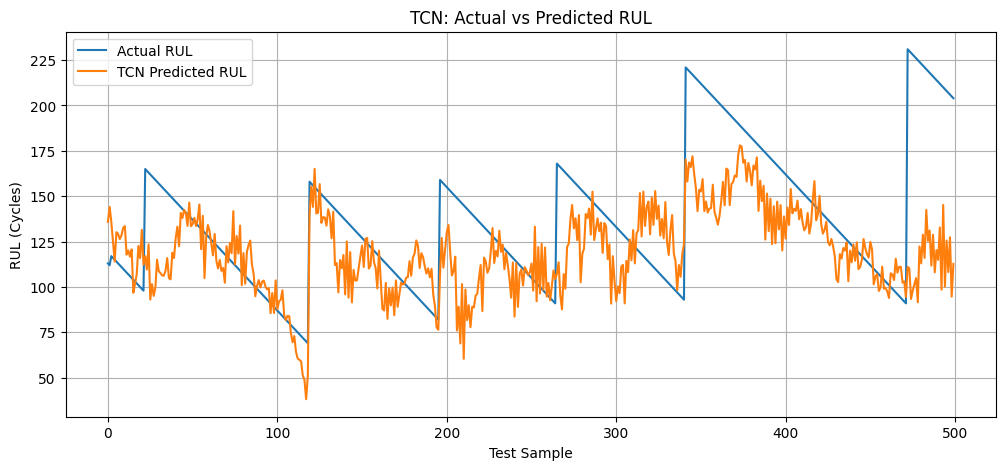

In [55]:
plt.figure(figsize=(12, 5))

plt.plot(
    actuals[:500],
    label="Actual RUL"
)

plt.plot(
    predictions[:500],
    label="TCN Predicted RUL"
)

plt.xlabel("Test Sample")
plt.ylabel("RUL (Cycles)")
plt.title("TCN: Actual vs Predicted RUL")

plt.legend()
plt.grid(True)

plt.show()

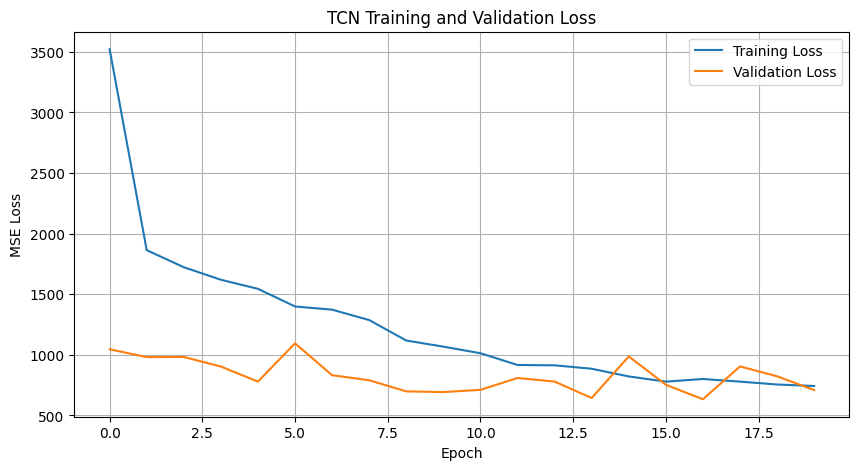

In [56]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("TCN Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

## TCN Evaluation Summary

The Temporal Convolutional Network (TCN) was developed as an additional temporal modeling approach for Remaining Useful Life (RUL) prediction.

The model used 30-cycle temporal windows containing 14 selected sensor measurements.

Test performance:

- MAE: 30.6166 cycles
- RMSE: 42.0461 cycles
- R²: 0.4067

The TCN was compared with the existing machine-learning models. XGBoost achieved an R² of 0.7184 and RMSE of 35.8687, while Random Forest achieved an R² of 0.7167 and RMSE of 35.9773.

Based on the evaluation, the existing XGBoost model remains the primary predictive model for the deployed system. The TCN is retained as an experimental temporal deep-learning benchmark.